# Kaggriculture: PPO + League Self-Play

Full pipeline: observation encoding, macro action space with legality masking, asset-based reward shaping, recurrent PPO with correct chunked truncated-BPTT, and league-based self-play.

## Imports & setup

In [1]:
import copy
import os
import random
import numbers

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

try:
    import ipywidgets  # noqa: F401 -- presence check only
    from tqdm.notebook import trange
except ImportError:
    from tqdm import trange  # falls back to a plain text bar if ipywidgets isn't installed

from kaggle_environments import make

CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 24.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_clobber
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environment

## Observation Encoder

In [2]:
class ObservationEncoder:
    CROP_TYPES = ["WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON"]
    ANIMAL_TYPES = ["GOOSE", "COW", "SHEEP"]
    SELLABLE_ITEMS = ["WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON",
                      "EGG", "MILK", "WOOL", "FERTILIZER"]
    SHOP_TYPES = ["BAKERY", "PIZZA_SHOP", "BRUNCH_SPOT", "YARN_STORE",
                  "ICE_CREAM_SHOP", "PET_CAFE", "SMOOTHIE_SHOP", "FARMERS_MARKET"]

    def __init__(self, board_size=10, include_opponent=True):
        self.board_size = board_size
        self.include_opponent = include_opponent
        self.tile_vec_len = 25
        self.market_town_vec_len = 9 + 9 + len(self.SHOP_TYPES)
        self.private_vec_len = 9 + 5 + 4

    def encode_tile(self, tile):
        vec = np.zeros(self.tile_vec_len, dtype=np.float32)
        if tile is None:
            vec[0] = 1.0
        elif tile == "LOCKED":
            vec[1] = 1.0
        elif isinstance(tile, dict):
            kind = tile.get("kind")
            if kind == "PLANT":
                vec[2] = 1.0
                crop = tile.get("crop", "")
                if crop in self.CROP_TYPES:
                    vec[3 + self.CROP_TYPES.index(crop)] = 1.0
                vec[8] = tile.get("planted_day", 0) / 30.0
                vec[9] = float(tile.get("watered_today", False))
                vec[10] = tile.get("yield_units", 0) / 6.0
                vec[11] = tile.get("fertilized_until_day", -1) / 30.0
                vec[12] = tile.get("consecutive_unwatered", 0) / 2.0
            elif kind == "WEED":
                vec[13] = 1.0
            elif kind in ("COOP", "PASTURE"):
                vec[14] = 1.0 if kind == "COOP" else 0.0
                vec[15] = 1.0 if kind == "PASTURE" else 0.0
                animal = tile.get("animal")
                if animal is None:
                    vec[16] = 1.0
                else:
                    if animal in self.ANIMAL_TYPES:
                        vec[17 + self.ANIMAL_TYPES.index(animal)] = 1.0
                    vec[20] = tile.get("placed_day", 0) / 30.0
                    vec[21] = tile.get("yield_units", 0) / 6.0
                    vec[22] = float(tile.get("fed_today", False))
                    vec[23] = float(tile.get("cared_today", False))
                    vec[24] = float(tile.get("fertilizer_available", False))
        return vec

    def encode_farm(self, farm):
        n_tiles = self.board_size * self.board_size
        grid = np.zeros(n_tiles * self.tile_vec_len, dtype=np.float32)
        idx = 0
        for y in range(self.board_size):
            for x in range(self.board_size):
                grid[idx:idx + self.tile_vec_len] = self.encode_tile(farm["tiles"][y][x])
                idx += self.tile_vec_len
        return grid

    def encode_market_town(self, obs):
        market = obs["market"]
        prices = np.zeros(len(self.SELLABLE_ITEMS), dtype=np.float32)
        inventories = np.zeros(len(self.SELLABLE_ITEMS), dtype=np.float32)
        for i, item in enumerate(self.SELLABLE_ITEMS):
            prices[i] = market["prices"].get(item, 0) / 100.0
            inventories[i] = (market["inventory"].get(item, 0) - 10000.0) / 1000.0
        shop_counts = np.zeros(len(self.SHOP_TYPES), dtype=np.float32)
        for s in obs["town"]["unlocked_shops"]:
            if s in self.SHOP_TYPES:
                shop_counts[self.SHOP_TYPES.index(s)] += 1.0
        return np.concatenate([prices, inventories, shop_counts]).astype(np.float32)

    def encode_private(self, obs, player=None):
        if player is None:
            player = obs["player"]
        private = obs["private"]
        farm = obs["farms"][player]
        shed = np.zeros(len(self.SELLABLE_ITEMS), dtype=np.float32)
        for i, item in enumerate(self.SELLABLE_ITEMS):
            shed[i] = private["shed"].get(item, 0) / 10.0
        seeds = np.zeros(len(self.CROP_TYPES), dtype=np.float32)
        for i, crop in enumerate(self.CROP_TYPES):
            seeds[i] = private["seeds"].get(crop, 0) / 5.0
        money = farm["money"] / 10000.0
        hires = farm["hires_today"] / 5.0
        day = obs["day"] / 30.0
        hour = obs["hour"] / 24.0
        return np.concatenate([shed, seeds, [money, hires, day, hour]]).astype(np.float32)

    def encode(self, obs):
        player = obs["player"]
        board_size = len(obs["farms"][0]["tiles"])
        if board_size != self.board_size:
            self.board_size = board_size
        own_farm = obs["farms"][player]
        parts = [self.encode_farm(own_farm)]
        if self.include_opponent and len(obs["farms"]) > 1:
            parts.append(self.encode_farm(obs["farms"][1 - player]))
        parts.append(self.encode_market_town(obs))
        parts.append(self.encode_private(obs, player))
        return np.concatenate(parts).astype(np.float32)

    def encode_global(self, obs_list, perspective=0):
        p = perspective
        other = 1 - p
        farms = obs_list[0]["farms"]
        market_town = self.encode_market_town(obs_list[0])
        own_farm = self.encode_farm(farms[p])
        opp_farm = self.encode_farm(farms[other])
        own_private = self.encode_private(obs_list[p], player=p)
        opp_private = self.encode_private(obs_list[other], player=other)
        return np.concatenate([own_farm, opp_farm, market_town, own_private, opp_private]).astype(np.float32)

    @property
    def output_dim(self):
        n_farm = self.board_size * self.board_size * self.tile_vec_len
        n_farms = 1 + (1 if self.include_opponent else 0)
        return n_farms * n_farm + self.market_town_vec_len + self.private_vec_len

    @property
    def global_dim(self):
        n_farm = self.board_size * self.board_size * self.tile_vec_len
        return 2 * n_farm + self.market_town_vec_len + 2 * self.private_vec_len


## Macro Action Executor (v2) -- with `legal_macros()` masking

In [3]:
"""
MacroActionExecutor v2.

Verified directly against the installed kaggle_environments source
(envs/kaggriculture/kaggriculture.py) rather than assumed. Key facts that
drove the redesign:

- Every player starts with 0 seeds of every crop (_new_private). PLANT is
  useless unless something actually calls BUY_SEED first.
- HARVEST deposits into the acting unit's *inventory*, not the shed. SELL
  reads from the *shed*. The two only reconcile via the automatic
  end-of-day _drop_inventories_to_shed flush (once per ~24 turns) unless
  you explicitly walk a unit to a shed-adjacent tile and DROP.
- BUY_ANIMAL deposits into the *shed*. Getting an animal onto a COOP/
  PASTURE tile requires PICKUP (shed -> inventory) then PLACE.
- An animal that goes 2 consecutive days unfed escapes (you lose the
  purchase). FEED is urgent, not optional, once you own animals.
- Hire cost is fib(hires_today) * mult, not flat -- see _hire_cost.
- "Atomic PLANT validation": if this turn's total PLANT requests for one
  crop exceed available seed count, ALL of them are dropped, not just the
  excess. Any macro that routes multiple units into planting must respect
  this itself.
"""

import numpy as np

# Mirrors kaggle_environments.envs.kaggriculture.kaggriculture -- keep in
# sync with the installed package version. Also importable directly:
#   from kaggle_environments.envs.kaggriculture.kaggriculture import CROPS, ANIMALS, MARKET_PARAMS
CROPS = {
    "WHEAT":      {"seed": 10, "first_yield_day": 2, "max_yield_day": 4, "interval": 0, "max_yield": 6, "ongoing": False},
    "CARROT":     {"seed": 20, "first_yield_day": 2, "max_yield_day": 3, "interval": 0, "max_yield": 4, "ongoing": False},
    "TOMATO":     {"seed": 50, "first_yield_day": 8, "max_yield_day": 8, "interval": 1, "max_yield": 4, "ongoing": True},
    "STRAWBERRY": {"seed": 100, "first_yield_day": 10, "max_yield_day": 10, "interval": 2, "max_yield": 4, "ongoing": True},
    "MELON":      {"seed": 80, "first_yield_day": 10, "max_yield_day": 12, "interval": 0, "max_yield": 6, "ongoing": False},
}

ANIMALS = {
    "GOOSE": {"cost": 300, "structure": "COOP", "first_yield_day": 4, "interval": 1, "max_held": 4, "product": "EGG"},
    "COW":   {"cost": 400, "structure": "PASTURE", "first_yield_day": 8, "interval": 2, "max_held": 6, "product": "MILK"},
    "SHEEP": {"cost": 500, "structure": "PASTURE", "first_yield_day": 6, "interval": 3, "max_held": 6, "product": "WOOL"},
}

MARKET_BASE_PRICE = {
    "WHEAT": 25, "CARROT": 35, "TOMATO": 60, "STRAWBERRY": 120, "MELON": 250,
    "EGG": 50, "MILK": 160, "WOOL": 200, "FERTILIZER": 100,
}


class MacroActionExecutor:
    def __init__(self, board_size=10, sell_price_floor_frac=0.5):
        self.board_size = board_size
        # Don't sell a product below this fraction of its base price -- avoid
        # dumping into a depressed market. Tune per-item via MARKET_BASE_PRICE
        # if you want asymmetric thresholds later.
        self.sell_price_floor_frac = sell_price_floor_frac

        macros = [
            self._do_nothing,
            self._water_all,
            self._harvest_ready,
            self._sell_ready,
            self._hire_hand,
            self._buy_land,
            self._feed_animals,
            self._care_animals,
            self._fertilize_ready,
        ]
        for crop in CROPS:
            macros.append(self._make_plant_macro(crop))
        for animal in ANIMALS:
            macros.append(self._make_buy_place_animal_macro(animal))

        self.macro_handlers = {i: fn for i, fn in enumerate(macros)}

    def execute(self, obs, macro_id):
        if macro_id not in self.macro_handlers:
            return {"farmer": ["PASS"], "hands": [], "market": []}
        return self.macro_handlers[macro_id](obs)

    @property
    def num_macros(self):
        return len(self.macro_handlers)

    def legal_macros(self, obs):
        """Boolean mask over macro_handlers: True where the macro will
        actually do something this turn, False where it's a guaranteed
        no-op given the current obs. Cheap precondition checks mirroring
        each macro's internal guard clauses -- predicts without executing."""
        player = obs["player"]
        farm = obs["farms"][player]
        private = obs["private"]
        money = farm["money"]
        day = obs["day"]

        def any_tile(cond):
            for row in farm["tiles"]:
                for tile in row:
                    if cond(tile):
                        return True
            return False

        mask = np.zeros(self.num_macros, dtype=bool)
        for i, fn in self.macro_handlers.items():
            name = fn.__name__
            if name == "_do_nothing":
                mask[i] = True
            elif name == "_water_all":
                mask[i] = any_tile(self._is_unwatered)
            elif name == "_harvest_ready":
                mask[i] = any_tile(self._is_harvestable)
            elif name == "_sell_ready":
                shed = private["shed"]
                prices = obs["market"]["prices"]
                mask[i] = any(
                    shed.get(item, 0) > 0 and
                    prices.get(item, 0) >= self.sell_price_floor_frac * MARKET_BASE_PRICE.get(item, 0)
                    for item in MARKET_BASE_PRICE
                )
            elif name == "_hire_hand":
                n = farm["hires_today"]
                mask[i] = n < 5 and money >= self._hire_cost(n)
            elif name == "_buy_land":
                land_order = ["NE", "SW", "SE"]
                land_prices = [1000, 2000, 4000]
                n_extra = len(farm["unlocked_quadrants"]) - 1
                mask[i] = n_extra < len(land_order) and money >= land_prices[n_extra]
            elif name == "_feed_animals":
                mask[i] = any_tile(lambda t: self._is_animal(t) and not t.get("fed_today", False))
            elif name == "_care_animals":
                mask[i] = any_tile(lambda t: self._is_animal(t) and not t.get("cared_today", False))
            elif name == "_fertilize_ready":
                has_fert = private.get("inventories", [{}])[0].get("FERTILIZER", 0) > 0
                needs_it = any_tile(lambda t: self._is_plant(t) and t.get("fertilized_until_day", -1) < day)
                has_ready = any_tile(lambda t: self._is_animal(t) and t.get("fertilizer_available", False))
                mask[i] = (has_fert and needs_it) or has_ready
            elif name.startswith("_plant_"):
                crop = name.replace("_plant_", "").upper()
                seeds = private["seeds"].get(crop, 0)
                can_afford_one = money >= CROPS[crop]["seed"]
                has_empty_tile = any_tile(self._is_empty)
                mask[i] = has_empty_tile and (seeds > 0 or can_afford_one)
            elif name.startswith("_buy_place_"):
                animal = name.replace("_buy_place_", "").upper()
                carrying = private.get("inventories", [{}])[0].get(animal, 0) > 0
                in_shed = private["shed"].get(animal, 0) > 0
                can_afford = money >= ANIMALS[animal]["cost"]
                mask[i] = carrying or in_shed or can_afford
            else:
                mask[i] = True

        if not mask.any():
            mask[0] = True
        return mask


    # ---------------- generic helpers ----------------

    def _pos_to_dir(self, fx, fy, tx, ty):
        if fx < tx: return "EAST"
        if fx > tx: return "WEST"
        if fy < ty: return "SOUTH"
        if fy > ty: return "NORTH"
        return None

    def _nearest_tile(self, farm, condition, from_pos, exclude=None):
        exclude = exclude or set()
        best, best_dist = None, 10**9
        for y in range(self.board_size):
            for x in range(self.board_size):
                if (x, y) in exclude:
                    continue
                tile = farm["tiles"][y][x]
                if condition(tile):
                    dist = abs(x - from_pos[0]) + abs(y - from_pos[1])
                    if dist < best_dist:
                        best, best_dist = (x, y), dist
        return best

    def _is_plant(self, tile):
        return isinstance(tile, dict) and tile.get("kind") == "PLANT"

    def _is_animal(self, tile):
        return isinstance(tile, dict) and "animal" in tile

    def _is_unwatered(self, tile):
        return self._is_plant(tile) and not tile.get("watered_today", False)

    def _is_harvestable(self, tile):
        """Broadened vs. the original: crops AND animal products both harvest
        via the same HARVEST op, so one macro can cover both."""
        if self._is_plant(tile) and tile.get("yield_units", 0) > 0:
            return True
        if self._is_animal(tile) and tile.get("yield_units", 0) > 0:
            return True
        return False

    def _is_empty(self, tile):
        return tile is None

    def _units(self, farm):
        hands = farm.get("hands", [])
        return [("farmer", tuple(farm["farmer"]))] + [("hand", tuple(h)) for h in hands]

    def _route_units(self, farm, units, is_target, on_target_action):
        """
        Shared multi-unit dispatcher: each unit either acts (if standing on
        an unclaimed target tile) or takes one step toward the nearest
        unclaimed target. `claimed` prevents two units converging on the
        same single tile in one call -- the bug in the original executor.
        Returns (farmer_action, [hand_actions...]).
        """
        claimed = set()
        farmer_action = ["PASS"]
        hand_actions = []
        for unit_type, pos in units:
            fx, fy = pos
            tile = farm["tiles"][fy][fx]
            if (fx, fy) not in claimed and is_target(tile):
                action = list(on_target_action)
                claimed.add((fx, fy))
            else:
                target = self._nearest_tile(farm, is_target, (fx, fy), exclude=claimed)
                if target:
                    claimed.add(target)
                    step = self._pos_to_dir(fx, fy, target[0], target[1])
                    action = [step] if step else ["PASS"]
                else:
                    action = ["PASS"]
            if unit_type == "farmer":
                farmer_action = action
            else:
                hand_actions.append(action)
        return farmer_action, hand_actions

    def _shed_adjacent_tiles(self):
        half = self.board_size // 2
        return {(half - 1, half - 1), (half, half - 1), (half - 1, half), (half, half)}

    # ---------------- macros ----------------

    def _do_nothing(self, obs):
        return {"farmer": ["PASS"], "hands": [], "market": []}

    def _make_plant_macro(self, crop):
        def macro(obs):
            player = obs["player"]
            farm = obs["farms"][player]
            private = obs["private"]
            seeds = private["seeds"].get(crop, 0)   # ACTUAL current seed count
            money = farm["money"]
            market = []
            units = self._units(farm)
    
            # ---------------------------------------------------------------
            # 1) No seeds: buy ONE and do NOT attempt to plant.
            #    The seed will be available next turn.
            # ---------------------------------------------------------------
            if seeds == 0:
                seed_cost = CROPS[crop]["seed"]
                if money >= seed_cost:
                    market.append(["BUY_SEED", crop, 1])
                return {"farmer": ["PASS"], "hands": [], "market": market}
    
            # ---------------------------------------------------------------
            # 2) We have seeds: plant as many as we can with ACTUAL seeds.
            #    No buying this turn, no optimistic local seed increments.
            # ---------------------------------------------------------------
            plant_budget = [seeds]
    
            claimed = set()
            farmer_action = ["PASS"]
            hand_actions = []
    
            for unit_type, pos in units:
                fx, fy = pos
                tile = farm["tiles"][fy][fx]
    
                if (fx, fy) not in claimed and tile is None and plant_budget[0] > 0:
                    action = ["PLANT", crop]
                    plant_budget[0] -= 1
                    claimed.add((fx, fy))
                elif tile is None and plant_budget[0] <= 0:
                    # standing on empty but no seeds left -> hold
                    action = ["PASS"]
                else:
                    # move toward nearest empty tile to plant later
                    target = self._nearest_tile(farm, self._is_empty, (fx, fy), exclude=claimed)
                    if target:
                        claimed.add(target)
                        step = self._pos_to_dir(fx, fy, target[0], target[1])
                        action = [step] if step else ["PASS"]
                    else:
                        action = ["PASS"]
    
                if unit_type == "farmer":
                    farmer_action = action
                else:
                    hand_actions.append(action)
    
            return {"farmer": farmer_action, "hands": hand_actions, "market": market}
    
        macro.__name__ = f"_plant_{crop.lower()}"
        return macro

    def _water_all(self, obs):
        player = obs["player"]
        farm = obs["farms"][player]
        units = self._units(farm)
        farmer_action, hand_actions = self._route_units(farm, units, self._is_unwatered, ["WATER"])
        return {"farmer": farmer_action, "hands": hand_actions, "market": []}

    def _harvest_ready(self, obs):
        player = obs["player"]
        farm = obs["farms"][player]
        units = self._units(farm)
        farmer_action, hand_actions = self._route_units(farm, units, self._is_harvestable, ["HARVEST"])
        return {"farmer": farmer_action, "hands": hand_actions, "market": []}

    def _sell_ready(self, obs):
        """Sell everything in the shed whose current price clears the floor,
        instead of unconditionally dumping one hardcoded crop."""
        shed = obs["private"]["shed"]
        prices = obs["market"]["prices"]
        market = []
        for item, qty in shed.items():
            if qty <= 0:
                continue
            base = MARKET_BASE_PRICE.get(item)
            price = prices.get(item, 0)
            if base and price < self.sell_price_floor_frac * base:
                continue  # market's depressed on this item right now, hold
            market.append(["SELL", item, int(qty)])
        return {"farmer": ["PASS"], "hands": [], "market": market}

    def _hire_hand(self, obs):
        farm = obs["farms"][obs["player"]]
        n_hired = farm["hires_today"]
        if n_hired >= 5:
            return {"farmer": ["PASS"], "hands": [], "market": []}
        cost = self._hire_cost(n_hired)
        if farm["money"] >= cost:
            return {"farmer": ["PASS"], "hands": [], "market": [["HIRE"]]}
        return {"farmer": ["PASS"], "hands": [], "market": []}

    @staticmethod
    def _hire_cost(n_already_today, mult=1):
        a, b = 1, 1
        for _ in range(n_already_today):
            a, b = b, a + b
        return mult * a

    def _buy_land(self, obs):
        farm = obs["farms"][obs["player"]]
        land_order = ["NE", "SW", "SE"]
        land_prices = [1000, 2000, 4000]
        n_extra = len(farm["unlocked_quadrants"]) - 1
        if n_extra >= len(land_order):
            return {"farmer": ["PASS"], "hands": [], "market": []}
        if farm["money"] >= land_prices[n_extra]:
            return {"farmer": ["PASS"], "hands": [], "market": [["BUY_LAND"]]}
        return {"farmer": ["PASS"], "hands": [], "market": []}

    def _feed_animals(self, obs):
        """Highest practical priority once you own animals: 2 consecutive
        unfed days loses the animal outright. Auto-restocks WHEAT from the
        shed via PICKUP if the unit standing on the animal has none."""
        player = obs["player"]
        farm = obs["farms"][player]
        private = obs["private"]
        units = self._units(farm)

        def needs_feed(tile):
            return self._is_animal(tile) and not tile.get("fed_today", False)

        claimed = set()
        farmer_action = ["PASS"]
        hand_actions = []
        for i, (unit_type, pos) in enumerate(units):
            fx, fy = pos
            tile = farm["tiles"][fy][fx]
            inv = private["inventories"][i] if i < len(private.get("inventories", [])) else {}
            if (fx, fy) not in claimed and needs_feed(tile):
                if inv.get("WHEAT", 0) > 0:
                    action = ["FEED"]
                elif (fx, fy) in self._shed_adjacent_tiles() and private["shed"].get("WHEAT", 0) > 0:
                    action = ["PICKUP", "WHEAT", 1]  # next call will FEED
                else:
                    action = ["PASS"]
                claimed.add((fx, fy))
            else:
                target = self._nearest_tile(farm, needs_feed, (fx, fy), exclude=claimed)
                if target:
                    claimed.add(target)
                    step = self._pos_to_dir(fx, fy, target[0], target[1])
                    action = [step] if step else ["PASS"]
                else:
                    action = ["PASS"]
            if unit_type == "farmer":
                farmer_action = action
            else:
                hand_actions.append(action)
        return {"farmer": farmer_action, "hands": hand_actions, "market": []}

    def _care_animals(self, obs):
        farm = obs["farms"][obs["player"]]
        units = self._units(farm)

        def needs_care(tile):
            return self._is_animal(tile) and not tile.get("cared_today", False)

        farmer_action, hand_actions = self._route_units(farm, units, needs_care, ["CARE"])
        return {"farmer": farmer_action, "hands": hand_actions, "market": []}

    def _fertilize_ready(self, obs):
        """Applies FERTILIZER (from inventory) to any owned crop tile that
        isn't already under an active fertilizer bonus. If none carries
        FERTILIZER, tries to COLLECT_FERTILIZER off a ready animal tile
        instead of no-opping."""
        player = obs["player"]
        farm = obs["farms"][player]
        private = obs["private"]
        day = obs.get("day", 0)
        units = self._units(farm)

        def needs_fertilizer(tile):
            return self._is_plant(tile) and tile.get("fertilized_until_day", -1) < day

        def has_fertilizer_ready(tile):
            return self._is_animal(tile) and tile.get("fertilizer_available", False)

        claimed = set()
        farmer_action = ["PASS"]
        hand_actions = []
        for i, (unit_type, pos) in enumerate(units):
            fx, fy = pos
            tile = farm["tiles"][fy][fx]
            inv = private["inventories"][i] if i < len(private.get("inventories", [])) else {}
            if (fx, fy) not in claimed and needs_fertilizer(tile) and inv.get("FERTILIZER", 0) > 0:
                action = ["FERTILIZE"]
                claimed.add((fx, fy))
            elif (fx, fy) not in claimed and has_fertilizer_ready(tile):
                action = ["COLLECT_FERTILIZER"]
                claimed.add((fx, fy))
            else:
                # Prefer heading toward a fertilizer pickup if we're empty-handed,
                # otherwise toward a tile that needs fertilizing.
                if inv.get("FERTILIZER", 0) > 0:
                    target = self._nearest_tile(farm, needs_fertilizer, (fx, fy), exclude=claimed)
                else:
                    target = self._nearest_tile(farm, has_fertilizer_ready, (fx, fy), exclude=claimed)
                if target:
                    claimed.add(target)
                    step = self._pos_to_dir(fx, fy, target[0], target[1])
                    action = [step] if step else ["PASS"]
                else:
                    action = ["PASS"]
            if unit_type == "farmer":
                farmer_action = action
            else:
                hand_actions.append(action)
        return {"farmer": farmer_action, "hands": hand_actions, "market": []}

    def _make_buy_place_animal_macro(self, animal):
        structure = ANIMALS[animal]["structure"]
        cost = ANIMALS[animal]["cost"]

        def macro(obs):
            player = obs["player"]
            farm = obs["farms"][player]
            private = obs["private"]
            money = farm["money"]
            shed_stock = private["shed"].get(animal, 0)
            market = []

            fx, fy = farm["farmer"]
            farmer_inv = private["inventories"][0] if private.get("inventories") else {}

            # Already carrying one -> find a free structure and place it.
            if farmer_inv.get(animal, 0) > 0:
                def is_free_structure(tile):
                    return isinstance(tile, dict) and tile.get("kind") == structure and "animal" not in tile

                current_tile = farm["tiles"][fy][fx]
                if is_free_structure(current_tile):
                    return {"farmer": ["PLACE", animal], "hands": [], "market": []}
                target = self._nearest_tile(farm, is_free_structure, (fx, fy))
                if target:
                    step = self._pos_to_dir(fx, fy, target[0], target[1])
                    if step:
                        return {"farmer": [step], "hands": [], "market": []}
                # No free structure exists -- build one if standing on empty land.
                if farm["tiles"][fy][fx] is None:
                    build_op = "BUILD_COOP" if structure == "COOP" else "BUILD_PASTURE"
                    return {"farmer": [build_op], "hands": [], "market": []}
                empty = self._nearest_tile(farm, self._is_empty, (fx, fy))
                if empty:
                    step = self._pos_to_dir(fx, fy, empty[0], empty[1])
                    if step:
                        return {"farmer": [step], "hands": [], "market": []}
                return {"farmer": ["PASS"], "hands": [], "market": []}

            # Have one in the shed -> pick it up (must be shed-adjacent).
            if shed_stock > 0:
                if (fx, fy) in self._shed_adjacent_tiles():
                    return {"farmer": ["PICKUP", animal, 1], "hands": [], "market": []}
                target = self._nearest_tile(
                    farm, lambda t: True, (fx, fy)  # placeholder, replaced below
                )
                # Route toward any shed-adjacent tile explicitly.
                shed_tiles = self._shed_adjacent_tiles()
                best, best_dist = None, 10**9
                for (tx, ty) in shed_tiles:
                    d = abs(tx - fx) + abs(ty - fy)
                    if d < best_dist:
                        best, best_dist = (tx, ty), d
                if best:
                    step = self._pos_to_dir(fx, fy, best[0], best[1])
                    if step:
                        return {"farmer": [step], "hands": [], "market": []}
                return {"farmer": ["PASS"], "hands": [], "market": []}

            # Don't have one at all -> buy if affordable.
            if money >= cost:
                market.append(["BUY_ANIMAL", animal, 1])
            return {"farmer": ["PASS"], "hands": [], "market": market}

        macro.__name__ = f"_buy_place_{animal.lower()}"
        return macro


## Reward shaping: price the whole farm, not just liquid assets

In [4]:
def crop_in_ground_value(tile, prices, day):
    """Approximate fair value of a not-yet-harvested crop: linearly
    interpolate between 0 (just planted) and the full market value of its
    expected max yield, based on progress toward first_yield_day."""
    if not (isinstance(tile, dict) and tile.get("kind") == "PLANT"):
        return 0.0
    crop = tile.get("crop")
    info = CROPS.get(crop)
    if info is None:
        return 0.0
    planted_day = tile.get("planted_day", day)
    progress = (day - planted_day) / max(info["first_yield_day"], 1)
    progress = max(0.0, min(1.0, progress))
    expected_value = info["max_yield"] * prices.get(crop, MARKET_BASE_PRICE.get(crop, 0))
    return progress * expected_value


def animal_value(tile, day):
    """Approximate fair value of an owned animal: purchase cost, discounted
    if currently at risk of escaping (unfed today)."""
    if not (isinstance(tile, dict) and tile.get("animal")):
        return 0.0
    animal = tile["animal"]
    info = ANIMALS.get(animal)
    if info is None:
        return 0.0
    at_risk = not tile.get("fed_today", False)
    return info["cost"] * (0.6 if at_risk else 1.0)


def farm_asset_potential(farm, private, prices, day):
    """Extended potential: money + shed + growing crops + animals.
    Prices the WHOLE farm, not just liquid assets, so early investments
    (seed, animals, land) don't read as pure negative reward until sold."""
    money = farm["money"]
    shed = private["shed"]
    shed_value = sum(prices.get(item, 0) * shed.get(item, 0) for item in ObservationEncoder.SELLABLE_ITEMS)

    crop_value = 0.0
    animal_val = 0.0
    for row in farm["tiles"]:
        for tile in row:
            crop_value += crop_in_ground_value(tile, prices, day)
            animal_val += animal_value(tile, day)

    return money + shed_value + crop_value + animal_val


## Environment wrapper

In [5]:
class KaggricultureEnv:
    SELLABLE_ITEMS = ObservationEncoder.SELLABLE_ITEMS

    def __init__(self, executor=None, debug=False, shaping_gamma=1.0):
        self.env = make("kaggriculture", debug=debug)
        self.num_players = 2
        self.executor = executor
        self.shaping_gamma = shaping_gamma  # keep equal to PPOAgent's gamma --
        # Ng et al. 1999's exact policy-invariance guarantee for potential-based
        # shaping requires the same discount here as the agent trains with.
        self.reset()

    def reset(self):
        self.env.reset()
        self._last_obs = [self.env.steps[0][i].observation for i in range(self.num_players)]
        self.initial_money = {p: self._last_obs[p]["farms"][p]["money"] for p in range(self.num_players)}
        self._prev_potential = [self._compute_potential(obs) for obs in self._last_obs]
        return self._last_obs

    def step(self, actions):
        primitive_actions = {}
        for p in range(self.num_players):
            action = actions[p]
            if isinstance(action, numbers.Integral) and self.executor is not None:
                primitive_actions[p] = self.executor.execute(self._last_obs[p], int(action))
            elif isinstance(action, dict):
                primitive_actions[p] = action
            else:
                raise ValueError(f"Invalid action type for player {p}")
        self.env.step([primitive_actions[0], primitive_actions[1]])
        next_obs = [self.env.steps[-1][i].observation for i in range(self.num_players)]
        rewards = {}
        for p in range(self.num_players):
            pot_next = self._compute_potential(next_obs[p], is_terminal=self.env.done)
            rewards[p] = self.shaping_gamma * pot_next - self._prev_potential[p]
            self._prev_potential[p] = pot_next
        dones = {p: self.env.done for p in range(self.num_players)}
        self._last_obs = next_obs
        return next_obs, rewards, dones, None

    # def _compute_potential(self, obs, is_terminal=False):
    #     player = obs["player"]
    #     money = obs["farms"][player]["money"]
    #     if is_terminal:
    #         # Matches the ACTUAL scoring rule exactly (kaggriculture.py
    #         # interpreter sets s.reward = money at termination, nothing else).
    #         return money
    #     farm = obs["farms"][player]
    #     prices = obs["market"]["prices"]
    #     return farm_asset_potential(farm, obs["private"], prices, obs["day"])
    def _compute_potential(self, obs, is_terminal=False):
        player = obs["player"]
        money = obs["farms"][player]["money"]
        if is_terminal:
            return money
        shed = obs["private"]["shed"]
        prices = obs["market"]["prices"]
        shed_value = sum(prices.get(item,0)*shed.get(item,0) for item in self.SELLABLE_ITEMS)
        return money + shed_value


## Networks

In [6]:
class LSTMPolicy(nn.Module):
    def __init__(self, obs_dim, hidden_dim, num_actions):
        super().__init__()
        self.lstm = nn.LSTM(obs_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, num_actions)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        return self.head(out), hidden


class MLPCritic(nn.Module):
    def __init__(self, global_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(global_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, global_state):
        return self.net(global_state).squeeze(-1)


## PPO Agent (chunked truncated-BPTT, action masking, reward normalization)

In [7]:
class RunningStd:
    """Welford's online algorithm -- tracks a running std to rescale rewards
    without needing full history in memory. Scale only, don't subtract the
    mean, so the potential-based shaping guarantee isn't disturbed by an
    added per-step constant drift."""
    def __init__(self, eps=1e-4):
        self.mean = 0.0
        self.var = 1.0
        self.count = eps

    def update(self, x):
        # Cast every intermediate to plain Python float, not numpy scalar --
        # numpy scalar types stored inside a checkpoint dict get rejected by
        # torch.load's weights_only=True default (PyTorch >= 2.6), which
        # would otherwise break resuming from a saved checkpoint.
        batch_mean = float(np.mean(x))
        batch_var = float(np.var(x))
        batch_count = len(x)
        delta = batch_mean - self.mean
        tot_count = self.count + batch_count
        self.mean += delta * batch_count / tot_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + delta ** 2 * self.count * batch_count / tot_count
        self.var = float(M2 / tot_count)
        self.count = float(tot_count)

    @property
    def std(self):
        return np.sqrt(self.var) + 1e-8


class PPOAgent:
    def __init__(self, obs_dim, global_dim, num_actions, hidden_dim=128, lr=1e-4,
                 gamma=1.0, lam=0.95, clip_range=0.2, ppo_epochs=4, chunk_len=32,
                 entropy_coef=0.2, vf_coef=0.5, max_grad_norm=0.5, device="cuda"):
        self.obs_dim, self.global_dim, self.num_actions = obs_dim, global_dim, num_actions
        self.gamma, self.lam, self.clip_range = gamma, lam, clip_range
        self.ppo_epochs, self.chunk_len = ppo_epochs, chunk_len
        self.entropy_coef, self.vf_coef, self.max_grad_norm = entropy_coef, vf_coef, max_grad_norm
        self.device = device

        self.actor = LSTMPolicy(obs_dim, hidden_dim, num_actions).to(device)
        self.critic = MLPCritic(global_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=lr)

        self.episodes = []
        self._open = {}
        self.reward_rms = RunningStd()

    def new_hidden(self):
        return None

    def _masked_logits(self, logits, mask):
        if mask is None:
            return logits
        mask_t = torch.as_tensor(mask, dtype=torch.bool, device=self.device)
        return logits.masked_fill(~mask_t, float("-inf"))

    def act(self, obs, hidden, mask=None):
        with torch.no_grad():
            x = torch.as_tensor(obs, dtype=torch.float32, device=self.device).view(1, 1, -1)
            logits, new_hidden = self.actor(x, hidden)
            logits = self._masked_logits(logits.squeeze(0).squeeze(0), mask)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
        return action.item(), log_prob.item(), new_hidden

    def act_greedy(self, obs, hidden, mask=None):
        with torch.no_grad():
            x = torch.as_tensor(obs, dtype=torch.float32, device=self.device).view(1, 1, -1)
            logits, new_hidden = self.actor(x, hidden)
            logits = self._masked_logits(logits.squeeze(0).squeeze(0), mask)
            action = logits.argmax().item()
        return action, new_hidden

    def begin_episode(self, episode_id):
        self._open[episode_id] = {"obs": [], "act": [], "rew": [], "global": [],
                                   "done": [], "logp": [], "mask": []}

    def store(self, episode_id, obs, action, reward, global_state, done, log_prob, mask=None):
        ep = self._open[episode_id]
        ep["obs"].append(obs); ep["act"].append(action); ep["rew"].append(reward)
        ep["global"].append(global_state); ep["done"].append(done); ep["logp"].append(log_prob)
        ep["mask"].append(mask if mask is not None else np.ones(self.num_actions, dtype=bool))

    def end_episode(self, episode_id):
        ep = self._open.pop(episode_id)
        T = len(ep["obs"])
        if T == 0:
            return
        with torch.no_grad():
            global_t = torch.as_tensor(np.array(ep["global"], dtype=np.float32), device=self.device).unsqueeze(0)
            values = self.critic(global_t).squeeze(0).cpu().numpy()

        raw_rewards = np.array(ep["rew"], dtype=np.float32)
        # inside end_episode, before scaling
        print(f"Raw rewards: mean={raw_rewards.mean():.2f}, std={self.reward_rms.std:.2f}")
        self.reward_rms.update(raw_rewards)
        # rewards = raw_rewards / self.reward_rms.std
        rewards = raw_rewards   # instead of raw_rewards / self.reward_rms.std

        dones = np.array(ep["done"], dtype=np.float32)
        advantages = np.zeros(T, dtype=np.float32)
        next_value, next_adv = 0.0, 0.0
        for t in reversed(range(T)):
            delta = rewards[t] + self.gamma * next_value * (1 - dones[t]) - values[t]
            advantages[t] = delta + self.gamma * self.lam * (1 - dones[t]) * next_adv
            next_value, next_adv = values[t], advantages[t]
        returns = advantages + values
        adv_mean, adv_std = advantages.mean(), advantages.std()
        advantages = (advantages - adv_mean) / (adv_std + 1e-8)
        ep["adv"], ep["ret"] = advantages, returns
        self.episodes.append(ep)

    def update(self):
        if not self.episodes:
            return
        for _ in range(self.ppo_epochs):
            random.shuffle(self.episodes)
            for ep in self.episodes:
                self._update_on_episode(ep)
        self.episodes.clear()

    def _update_on_episode(self, ep):
        T = len(ep["obs"])
        obs = torch.as_tensor(np.array(ep["obs"], dtype=np.float32), device=self.device)
        acts = torch.as_tensor(np.array(ep["act"], dtype=np.int64), device=self.device)
        old_logp = torch.as_tensor(np.array(ep["logp"], dtype=np.float32), device=self.device)
        adv = torch.as_tensor(ep["adv"], dtype=torch.float32, device=self.device)
        ret = torch.as_tensor(ep["ret"], dtype=torch.float32, device=self.device)
        global_state = torch.as_tensor(np.array(ep["global"], dtype=np.float32), device=self.device)
        masks = torch.as_tensor(np.array(ep["mask"], dtype=bool), device=self.device)  # (T, num_actions)

        hidden = None
        for start in range(0, T, self.chunk_len):
            end = min(start + self.chunk_len, T)
            obs_chunk = obs[start:end].unsqueeze(0)
            act_chunk = acts[start:end].unsqueeze(0)
            old_logp_chunk = old_logp[start:end].unsqueeze(0)
            adv_chunk = adv[start:end].unsqueeze(0)
            ret_chunk = ret[start:end]
            global_chunk = global_state[start:end]
            mask_chunk = masks[start:end].unsqueeze(0)  # SAME mask rollout used, applied here too

            logits, hidden = self.actor(obs_chunk, hidden)
            logits = logits.masked_fill(~mask_chunk, float("-inf"))
            hidden = tuple(h.detach() for h in hidden)  # truncated BPTT: threaded forward, cut here

            dist = torch.distributions.Categorical(logits=logits)
            new_logp = dist.log_prob(act_chunk)
            entropy = dist.entropy().mean()

            ratio = torch.exp(new_logp - old_logp_chunk)
            surr1 = ratio * adv_chunk
            surr2 = torch.clamp(ratio, 1 - self.clip_range, 1 + self.clip_range) * adv_chunk
            actor_loss = -torch.min(surr1, surr2).mean()

            values_chunk = self.critic(global_chunk)
            critic_loss = F.mse_loss(values_chunk, ret_chunk)
            if start == 0 and random.random() < 0.05:
                print(f"  ratio mean={ratio.mean().item():.3f} max={ratio.max().item():.3f} "
                  f"adv mean={adv_chunk.mean().item():.3f} entropy={entropy.item():.3f} "
                  f"actor_loss={actor_loss.item():.3f} critic_loss={critic_loss.item():.3f}")

            total_loss = actor_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy

            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.max_grad_norm)
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), self.max_grad_norm)
            self.actor_optimizer.step()
            self.critic_optimizer.step()

    def actor_state_dict(self):
        return copy.deepcopy(self.actor.state_dict())

    def load_actor_state_dict(self, sd):
        self.actor.load_state_dict(sd)


class FrozenOpponent:
    def __init__(self, obs_dim, hidden_dim, num_actions, state_dict, device="cuda"):
        self.actor = LSTMPolicy(obs_dim, hidden_dim, num_actions).to(device)
        self.actor.load_state_dict(state_dict)
        self.actor.eval()
        self.device = device

    def act(self, obs, hidden, mask=None):
        with torch.no_grad():
            x = torch.as_tensor(obs, dtype=torch.float32, device=self.device).view(1, 1, -1)
            logits, new_hidden = self.actor(x, hidden)
            logits = logits.squeeze(0).squeeze(0)
            if mask is not None:
                mask_t = torch.as_tensor(mask, dtype=torch.bool, device=self.device)
                logits = logits.masked_fill(~mask_t, float("-inf"))
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
        return action.item(), new_hidden


class ScriptedOpponent:
    """Fixed, non-learning opponent -- same .act() interface as FrozenOpponent
    so it drops into run_episode() unchanged. Used for the curriculum/debug
    step: train against something with completely stable behavior first, to
    isolate whether the core reward+action pipeline can learn at all before
    self-play's moving-target non-stationarity is added to the mix."""
    def __init__(self, macro_id):
        self.macro_id = macro_id

    def act(self, obs, hidden, mask=None):
        return self.macro_id, hidden


class League:
    def __init__(self, max_size=20):
        self.max_size = max_size
        self.snapshots = []

    def add(self, actor_state_dict):
        snap = copy.deepcopy(actor_state_dict)
        if len(self.snapshots) >= self.max_size:
            self.snapshots.pop(0)
        self.snapshots.append(snap)

    def sample(self):
        return random.choice(self.snapshots) if self.snapshots else None

    def __len__(self):
        return len(self.snapshots)


## Training loop

In [8]:
def run_episode(env, encoder, executor, agent, opponent, self_play,
                max_steps=720, core_mask=None):
    obs = env.reset()
    done = False
    step = 0

    h0 = agent.new_hidden()
    h1 = agent.new_hidden() if self_play else None

    ep0 = "seat0"
    agent.begin_episode(ep0)
    if self_play:
        ep1 = "seat1"
        agent.begin_episode(ep1)

    while not done and step < max_steps:
        step += 1
        obs0 = encoder.encode(obs[0])
        obs1 = encoder.encode(obs[1])
        global0 = encoder.encode_global(obs, perspective=0)
        mask0 = executor.legal_macros(obs[0])
        mask1 = executor.legal_macros(obs[1])

        if core_mask is not None:
            mask0 = mask0 & core_mask
            mask1 = mask1 & core_mask

        action0, logp0, h0 = agent.act(obs0, h0, mask=mask0)
        if self_play:
            action1, logp1, h1 = agent.act(obs1, h1, mask=mask1)
        else:
            action1, h1 = opponent.act(obs1, h1, mask=mask1)

        next_obs, rewards, dones, _ = env.step({0: action0, 1: action1})
        done = dones[0]

        agent.store(ep0, obs0, action0, rewards[0], global0, done, logp0, mask=mask0)
        if self_play:
            global1 = encoder.encode_global(obs, perspective=1)
            agent.store(ep1, obs1, action1, rewards[1], global1, done, logp1, mask=mask1)

        obs = next_obs

    agent.end_episode(ep0)
    if self_play:
        agent.end_episode(ep1)

    return obs[0]["farms"][0]["money"], obs[1]["farms"][1]["money"]
    
def save_checkpoint(agent, league, history, path):
    torch.save({
        "actor": agent.actor.state_dict(),
        "critic": agent.critic.state_dict(),
        "actor_opt": agent.actor_optimizer.state_dict(),
        "critic_opt": agent.critic_optimizer.state_dict(),
        "reward_rms_mean": agent.reward_rms.mean,
        "reward_rms_var": agent.reward_rms.var,
        "reward_rms_count": agent.reward_rms.count,
        "league": league.snapshots,
        "history": history,
    }, path)


def load_checkpoint(agent, league, path):
    # weights_only=False: this checkpoint is something WE wrote (actor/critic
    # state dicts + optimizer state + our own RunningStd floats + league
    # snapshots), not a third-party file -- safe to fully unpickle here.
    # PyTorch >= 2.6 defaults weights_only=True, which would otherwise reject it.
    try:
        ckpt = torch.load(path, map_location=agent.device, weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location=agent.device)  # older torch, no such kwarg
    agent.actor.load_state_dict(ckpt["actor"])
    agent.critic.load_state_dict(ckpt["critic"])
    agent.actor_optimizer.load_state_dict(ckpt["actor_opt"])
    agent.critic_optimizer.load_state_dict(ckpt["critic_opt"])
    agent.reward_rms.mean = ckpt["reward_rms_mean"]
    agent.reward_rms.var = ckpt["reward_rms_var"]
    agent.reward_rms.count = ckpt["reward_rms_count"]
    league.snapshots = ckpt["league"]
    return ckpt.get("history", [])


def train_league_selfplay(
    agent,
    league,
    encoder,
    executor,
    env,
    num_iterations=50,
    episodes_per_iter=4,
    p_self_play=0.5,
    p_self_play_schedule=None,
    league_add_every=10,
    max_steps=720,
    checkpoint_every=10,
    checkpoint_path=None,
    history=None,
    fixed_opponent=None,
    core_actions=None,
    debug_reward_check=False,
):
    """
    Notebook-friendly training loop.
      - tqdm.notebook progress bar; Ctrl+C / Interrupt-kernel returns cleanly
        with whatever has been trained so far instead of losing it.
      - periodic checkpointing to disk (Kaggle sessions can time out).
      - `p_self_play_schedule(it) -> float` overrides `p_self_play` per
        iteration if given -- e.g. start at 0.0 and ramp up.
      - `fixed_opponent`: if given (e.g. a ScriptedOpponent), every episode
        is played against this SAME fixed opponent instead of self-play or
        the league -- this is the curriculum/debug step: isolate whether
        the core reward+action pipeline can learn at all before self-play's
        moving-target non-stationarity is added to the mix.
      - `core_actions`: optional list of macro IDs to restrict the action
        space during training. The agent will only be allowed to choose
        from these actions. Useful for curriculum learning (e.g., start
        with just wheat loop).
      - `debug_reward_check`: if True, after each episode prints the total
        shaped reward and compares it with the actual profit. Only valid
        when using simple potential + gamma=1.0.
      - safe to call again on the same agent/league/history to keep
        training incrementally across notebook sessions (pair with
        load_checkpoint at the top of a new session).
    """
    history = history if history is not None else []
    obs_dim, hidden_dim = encoder.output_dim, agent.actor.lstm.hidden_size
    num_actions = executor.num_macros

    if len(league) == 0:
        league.add(agent.actor_state_dict())

    # Build core mask if core_actions provided
    core_mask = None
    if core_actions is not None:
        core_mask = np.zeros(num_actions, dtype=bool)
        core_mask[core_actions] = True

    pbar = trange(num_iterations, desc="training")
    try:
        for it in pbar:
            current_p_self = p_self_play_schedule(it) if p_self_play_schedule else p_self_play
            iter_moneys = []
            for ep in range(episodes_per_iter):
                if fixed_opponent is not None:
                    m0, m1 = run_episode(
                        env, encoder, executor, agent,
                        opponent=fixed_opponent,
                        self_play=False,
                        max_steps=max_steps,
                        core_mask=core_mask,
                    )
                elif random.random() < current_p_self or len(league) == 0:
                    m0, m1 = run_episode(
                        env, encoder, executor, agent,
                        opponent=None,
                        self_play=True,
                        max_steps=max_steps,
                        core_mask=core_mask,
                    )
                else:
                    snap = league.sample()
                    opponent = FrozenOpponent(
                        obs_dim, hidden_dim, num_actions, snap, device=agent.device
                    )
                    m0, m1 = run_episode(
                        env, encoder, executor, agent,
                        opponent=opponent,
                        self_play=False,
                        max_steps=max_steps,
                        core_mask=core_mask,
                    )
                iter_moneys.append(m0)

                # ----- Reward telescoping check -----
                if debug_reward_check and agent.episodes:
                    last_ep = agent.episodes[-1]
                    raw_rew = np.array(last_ep["rew"])
                    total_shaped = float(raw_rew.sum())
                    initial_money = env.initial_money[0]
                    profit = m0 - initial_money
                    print(
                        f"  [check] ep {ep}: shaped_total={total_shaped:.2f}, "
                        f"final_money={m0:.2f}, start_money={initial_money:.2f}, "
                        f"profit={profit:.2f}, abs_diff={abs(total_shaped - profit):.4f}"
                    )

            agent.update()

            history.append(
                {
                    "iter": len(history),
                    "mean_money": float(np.mean(iter_moneys)),
                    "p_self_play": current_p_self,
                }
            )
            pbar.set_postfix(
                mean_money=f"{np.mean(iter_moneys):.0f}",
                league=len(league),
                p_self=f"{current_p_self:.2f}",
            )

            if (it + 1) % league_add_every == 0:
                league.add(agent.actor_state_dict())

            if checkpoint_path and (it + 1) % checkpoint_every == 0:
                save_checkpoint(agent, league, history, checkpoint_path)

    except KeyboardInterrupt:
        print("Interrupted -- returning current agent/league/history so far.")

    if checkpoint_path:
        save_checkpoint(agent, league, history, checkpoint_path)

    return agent, league, history

## Evaluation harness

In [9]:
def do_nothing_action(executor):
    return [i for i, fn in executor.macro_handlers.items() if fn.__name__ == "_do_nothing"][0]


def evaluate(agent, encoder, executor, env, opponent_state_dict=None, num_episodes=5,
             max_steps=720, hidden_dim=128, deterministic=True, verbose=True):
    obs_dim, num_actions = encoder.output_dim, executor.num_macros
    opponent = None
    if opponent_state_dict is not None:
        opponent = FrozenOpponent(obs_dim, hidden_dim, num_actions, opponent_state_dict)

    results = []
    for ep in range(num_episodes):
        obs = env.reset()
        done = False
        step = 0
        h0 = agent.new_hidden()
        h1 = agent.new_hidden() if opponent is not None else None

        while not done and step < max_steps:
            step += 1
            obs0 = encoder.encode(obs[0])
            obs1 = encoder.encode(obs[1])
            mask0 = executor.legal_macros(obs[0])
            mask1 = executor.legal_macros(obs[1])

            if deterministic:
                action0, h0 = agent.act_greedy(obs0, h0, mask=mask0)
            else:
                action0, _, h0 = agent.act(obs0, h0, mask=mask0)

            if opponent is not None:
                action1, h1 = opponent.act(obs1, h1, mask=mask1)
            else:
                action1 = do_nothing_action(executor)

            next_obs, rewards, dones, _ = env.step({0: action0, 1: action1})
            done = dones[0]
            obs = next_obs

        money0 = obs[0]["farms"][0]["money"]
        money1 = obs[1]["farms"][1]["money"]
        won = money0 > money1
        results.append((money0, money1, won))
        if verbose:
            print(f"[eval ep {ep+1}/{num_episodes}] agent_money={money0:.0f} "
                  f"opponent_money={money1:.0f} agent_won={won}")

    agent_moneys = [r[0] for r in results]
    win_rate = sum(r[2] for r in results) / len(results)
    print(f"\nMean agent final money: {np.mean(agent_moneys):.1f} "
          f"(+/- {np.std(agent_moneys):.1f})  |  win rate: {win_rate:.0%}")
    return results


def plot_training_curve(history):
    iters = [h["iter"] for h in history]
    money = [h["mean_money"] for h in history]
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(iters, money, label="mean money (self-play episodes)")
    ax1.set_xlabel("iteration")
    ax1.set_ylabel("mean money")
    if "p_self_play" in history[0]:
        ax2 = ax1.twinx()
        ax2.plot(iters, [h["p_self_play"] for h in history], color="gray", alpha=0.4, label="p_self_play")
        ax2.set_ylabel("p_self_play")
    fig.tight_layout()
    plt.show()


## Step 1: debug run against a fixed do-nothing opponent

obs_dim=5044 global_dim=5062 num_actions=17


training:   0%|          | 0/20 [00:00<?, ?it/s]

Raw rewards: mean=-23.22, std=1.00
  [check] ep 0: shaped_total=-16697.94, final_money=3021.00, start_money=2000.00, profit=1021.00, abs_diff=17718.9400
Raw rewards: mean=-23.10, std=15.37
  [check] ep 1: shaped_total=-16610.00, final_money=3065.00, start_money=2000.00, profit=1065.00, abs_diff=17675.0000
Raw rewards: mean=-20.94, std=17.60
  [check] ep 2: shaped_total=-15057.94, final_money=2628.00, start_money=2000.00, profit=628.00, abs_diff=15685.9400
Raw rewards: mean=-21.08, std=15.78
  [check] ep 3: shaped_total=-15156.93, final_money=2654.00, start_money=2000.00, profit=654.00, abs_diff=15810.9300
Raw rewards: mean=-23.22, std=14.89
  [check] ep 0: shaped_total=-16697.84, final_money=3376.00, start_money=2000.00, profit=1376.00, abs_diff=18073.8400
Raw rewards: mean=-22.69, std=15.75
  [check] ep 1: shaped_total=-16310.75, final_money=2909.00, start_money=2000.00, profit=909.00, abs_diff=17219.7500
Raw rewards: mean=-22.26, std=15.61
  [check] ep 2: shaped_total=-16007.32, fina

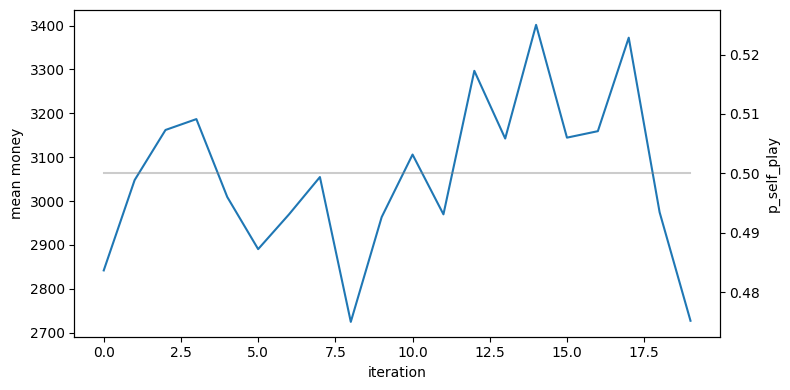

In [10]:
encoder = ObservationEncoder(board_size=10, include_opponent=True)
executor = MacroActionExecutor(board_size=10)
env = KaggricultureEnv(executor=executor, shaping_gamma=0.99)

obs_dim, global_dim, num_actions = encoder.output_dim, encoder.global_dim, executor.num_macros
print(f"obs_dim={obs_dim} global_dim={global_dim} num_actions={num_actions}")

agent = PPOAgent(obs_dim, global_dim, num_actions, hidden_dim=128, gamma=0.99, device="cuda")
league = League(max_size=20)

CKPT_PATH = os.path.join(CHECKPOINT_DIR, "kaggriculture_ppo.pt")

# --- Debug step: does the pipeline learn ANYTHING against a fixed,
# genuinely-passive do-nothing opponent, with zero self-play non-stationarity?
# Short and cheap -- this is a diagnostic, not the real training run. If mean
#  
# not in self-play dynamics -- keep debugging here before moving to cell 11.
do_nothing_opponent = ScriptedOpponent(do_nothing_action(executor))
core_actions = [0, 1, 2, 3, 9]

agent, league, history = train_league_selfplay(
    agent, league, encoder, executor, env,
    num_iterations=20, episodes_per_iter=4,
    fixed_opponent=do_nothing_opponent,
    core_actions=core_actions,
    debug_reward_check=True,
    league_add_every=5, max_steps=720,
    checkpoint_path=CKPT_PATH, checkpoint_every=5,
)
plot_training_curve(history)


In [11]:
# Manual cycle test -- must be run with the SIMPLE potential? No, we only need raw money.
executor = MacroActionExecutor(board_size=10)
env = KaggricultureEnv(executor=executor, debug=False, shaping_gamma=1.0)  # gamma doesn't matter here
obs = env.reset()

macro_cycle = [9, 1, 2, 3]  # plant_wheat, water_all, harvest_ready, sell_ready
for day in range(20):        # 10 days
    for hour in range(24):
        macro_id = macro_cycle[hour % 4]   # rotate actions
        actions = {0: macro_id, 1: 0}      # opponent does nothing
        obs, rewards, dones, _ = env.step(actions)
        if hour == 23:
            me = obs[0]['farms'][0]
            print(f"Day {day}: money={me['money']:.0f}, seeds={obs[0]['private']['seeds'].get('WHEAT',0)}, "
                  f"shed_wheat={obs[0]['private']['shed'].get('WHEAT',0)}, tiles_planted="
                  f"{sum(1 for row in me['tiles'] for t in row if isinstance(t,dict) and t.get('kind')=='PLANT')}")

Day 0: money=1980, seeds=1, shed_wheat=0, tiles_planted=1
Day 1: money=1980, seeds=1, shed_wheat=0, tiles_planted=1
Day 2: money=1970, seeds=1, shed_wheat=1, tiles_planted=1
Day 3: money=1999, seeds=1, shed_wheat=0, tiles_planted=1
Day 4: money=1989, seeds=1, shed_wheat=1, tiles_planted=1
Day 5: money=2018, seeds=1, shed_wheat=0, tiles_planted=1
Day 6: money=2008, seeds=1, shed_wheat=1, tiles_planted=1
Day 7: money=2039, seeds=1, shed_wheat=0, tiles_planted=1
Day 8: money=2029, seeds=1, shed_wheat=1, tiles_planted=1
Day 9: money=2063, seeds=1, shed_wheat=0, tiles_planted=1
Day 10: money=2053, seeds=1, shed_wheat=1, tiles_planted=1
Day 11: money=2090, seeds=1, shed_wheat=0, tiles_planted=1
Day 12: money=2080, seeds=1, shed_wheat=1, tiles_planted=1
Day 13: money=2120, seeds=1, shed_wheat=0, tiles_planted=1
Day 14: money=2110, seeds=1, shed_wheat=1, tiles_planted=1
Day 15: money=2152, seeds=1, shed_wheat=0, tiles_planted=1
Day 16: money=2142, seeds=1, shed_wheat=1, tiles_planted=1
Day 17:

## Step 2: real training run (ramped self-play curriculum)

training:   0%|          | 0/300 [00:00<?, ?it/s]

Raw rewards: mean=-2.77, std=15.57
Raw rewards: mean=-2.78, std=16.11
Raw rewards: mean=-2.77, std=17.70
Raw rewards: mean=-2.77, std=18.12
  ratio mean=0.953 max=1.198 adv mean=-3.282 entropy=2.453 actor_loss=3.033 critic_loss=329951.625
Raw rewards: mean=-2.77, std=18.53
Raw rewards: mean=-2.77, std=20.09
Raw rewards: mean=-2.68, std=21.30
Raw rewards: mean=-2.78, std=23.27
  ratio mean=0.977 max=1.162 adv mean=-1.104 entropy=1.604 actor_loss=1.048 critic_loss=265722.188
Raw rewards: mean=-2.78, std=23.88
Raw rewards: mean=-2.78, std=24.24
Raw rewards: mean=-2.77, std=24.43
Raw rewards: mean=-2.78, std=24.62
Raw rewards: mean=-2.77, std=24.80
Raw rewards: mean=-2.78, std=25.21
Raw rewards: mean=-2.78, std=26.56
Raw rewards: mean=-2.77, std=26.84
Raw rewards: mean=-2.78, std=27.14
  ratio mean=0.994 max=1.177 adv mean=-2.941 entropy=2.234 actor_loss=2.855 critic_loss=631978.750
  ratio mean=0.987 max=1.236 adv mean=-2.264 entropy=1.893 actor_loss=2.262 critic_loss=337303.906
  ratio m

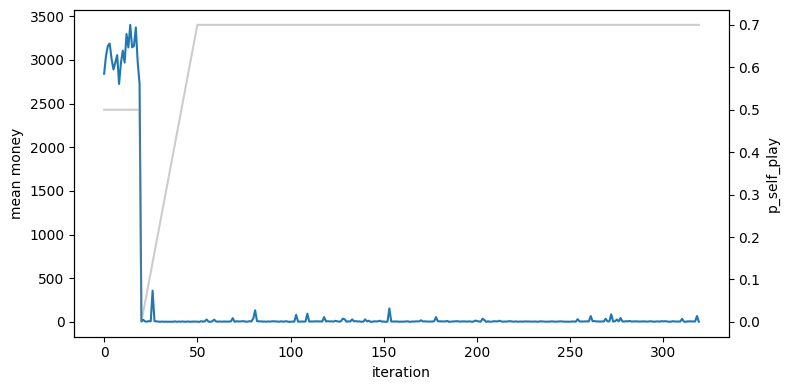

In [12]:
# --- Real training run: once cell 10 shows the pipeline learning against
# do-nothing, resume the SAME agent/league and ramp self-play in gradually
# (avoids dropping a barely-competent policy straight into a moving-target
# opponent, which is a common cause of stalls in self-play curricula).

def ramp_schedule(it, warmup_iters=30, final_p=0.7):
    return min(final_p, final_p * it / warmup_iters)

agent, league, history = train_league_selfplay(
    agent, league, encoder, executor, env,
    num_iterations=300, episodes_per_iter=4,
    p_self_play_schedule=ramp_schedule,
    league_add_every=15, max_steps=720,
    checkpoint_path=CKPT_PATH, checkpoint_every=10,
    history=history,   # continue the same curve from cell 10
)
plot_training_curve(history)

torch.save(agent.actor_state_dict(), os.path.join(CHECKPOINT_DIR, "actor_weights.pt"))


## Step 3: evaluate the trained agent

In [13]:
print("=== EVAL vs do-nothing baseline ===")
evaluate(agent, encoder, executor, env, opponent_state_dict=None, num_episodes=5)

print("\n=== EVAL vs earliest league snapshot ===")
evaluate(agent, encoder, executor, env, opponent_state_dict=league.snapshots[0], num_episodes=5)

print("\n=== EVAL vs latest league snapshot ===")
evaluate(agent, encoder, executor, env, opponent_state_dict=league.snapshots[-1], num_episodes=5)


=== EVAL vs do-nothing baseline ===
[eval ep 1/5] agent_money=730 opponent_money=2000 agent_won=False
[eval ep 2/5] agent_money=730 opponent_money=2000 agent_won=False
[eval ep 3/5] agent_money=730 opponent_money=2000 agent_won=False
[eval ep 4/5] agent_money=730 opponent_money=2000 agent_won=False
[eval ep 5/5] agent_money=730 opponent_money=2000 agent_won=False

Mean agent final money: 730.0 (+/- 0.0)  |  win rate: 0%

=== EVAL vs earliest league snapshot ===
[eval ep 1/5] agent_money=1690 opponent_money=0 agent_won=True
[eval ep 2/5] agent_money=1650 opponent_money=0 agent_won=True
[eval ep 3/5] agent_money=40 opponent_money=0 agent_won=True
[eval ep 4/5] agent_money=190 opponent_money=8 agent_won=True
[eval ep 5/5] agent_money=0 opponent_money=1 agent_won=False

Mean agent final money: 714.0 (+/- 783.2)  |  win rate: 80%

=== EVAL vs latest league snapshot ===
[eval ep 1/5] agent_money=30 opponent_money=0 agent_won=True
[eval ep 2/5] agent_money=30 opponent_money=0 agent_won=True
[

[(30.0, 0.0, True),
 (30.0, 0.0, True),
 (20.0, 2.0, True),
 (0.0, 7.0, False),
 (20.0, 4.0, True)]